In [16]:
import math
import numpy as np
import numba
import sqlite3
import os
import time

def init_polyconv_db(db_name='recursions_polyconv.db'):
    try:
        conn = sqlite3.connect(db_name, timeout=60.0)
        c = conn.cursor()
        c.execute('''CREATE TABLE IF NOT EXISTS polyconv_states
                     (n INTEGER, d INTEGER, b REAL, k_start INTEGER, logZ BLOB, prev_logZn REAL, small_count INTEGER, cumulative_capacity REAL,
                     PRIMARY KEY (n, d, b))''')
        conn.commit()
        conn.close()
    except Exception:
        pass

def save_polyconv_state(n, d, b, k_start, logZ, prev_logZn, small_count, cumulative_capacity, db_name='recursions_polyconv.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''INSERT OR REPLACE INTO polyconv_states (n, d, b, k_start, logZ, prev_logZn, small_count, cumulative_capacity)
                         VALUES (?, ?, ?, ?, ?, ?, ?, ?)''', 
                      (n, d, b, k_start, logZ.tobytes(), prev_logZn, small_count, cumulative_capacity))
            conn.commit()
            conn.close()
            break
        except sqlite3.OperationalError:
            time.sleep(2)

def load_polyconv_state(n, d, b, db_name='recursions_polyconv.db'):
    for _ in range(5):
        try:
            conn = sqlite3.connect(db_name, timeout=60.0)
            c = conn.cursor()
            c.execute('''SELECT n, k_start, logZ, prev_logZn, small_count, cumulative_capacity FROM polyconv_states WHERE d=? AND b=? AND n >= ? ORDER BY k_start DESC LIMIT 1''', (d, b, n))
            row = c.fetchone()
            conn.close()
            if row is None:
                return None
            saved_n = row[0]
            k_start = row[1]
            logZ_saved = np.frombuffer(row[2], dtype=np.float64)
            prev_logZn = row[3]
            small_count = row[4]
            cumulative_capacity = row[5]
            logZ = logZ_saved[:n + 1].copy()
            return k_start, logZ, prev_logZn, small_count, cumulative_capacity
        except sqlite3.OperationalError:
            time.sleep(2)
    return None

@numba.njit
def logaddexp(a, b):
    if a == -np.inf:
        return b
    if b == -np.inf:
        return a
    if a > b:
        return a + math.log1p(math.exp(b - a))
    else:
        return b + math.log1p(math.exp(a - b))

@numba.njit
def level_degeneracy_numba(d, k):
    if k == 0: return 1.0
    if d == 1: return 1.0
    res = 1.0
    for i in range(1, k + 1):
        res = res * (d + k - i) / i
    return res

@numba.njit
def log_binom(n, k):
    if k < 0 or k > n:
        return -np.inf
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)

@numba.njit
def _polyconv_fixed_chunk(k_start, k_end, logZ, d, logb, n):
    for k in range(k_start, k_end):
        g_float = level_degeneracy_numba(d, k)
        mmax = int(min(g_float, float(n)))
        logwk = k * logb
        
        logC = np.zeros(mmax + 1, dtype=np.float64)
        for m in range(1, mmax + 1):
            logC[m] = log_binom(g_float, m) + m * logwk
            
        old = logZ.copy()
        for r in range(n + 1):
            s = -np.inf
            upper = min(r, mmax)
            for m in range(upper + 1):
                if old[r - m] != -np.inf:
                    s = logaddexp(s, logC[m] + old[r - m])
            logZ[r] = s
    return logZ, k_end

@numba.njit
def _polyconv_adaptive_chunk(k_start, k_end, logZ, d, logb, n, tol, consecutive_small, cumulative_capacity, prev_logZn, small_count):
    stop_reached = False
    for k in range(k_start, k_end):
        g_float = level_degeneracy_numba(d, k)
        mmax = int(min(g_float, float(n)))
        logwk = k * logb
        
        logC = np.zeros(mmax + 1, dtype=np.float64)
        for m in range(1, mmax + 1):
            logC[m] = log_binom(g_float, m) + m * logwk
            
        old = logZ.copy()
        for r in range(n + 1):
            s = -np.inf
            upper = min(r, mmax)
            for m in range(upper + 1):
                if old[r - m] != -np.inf:
                    s = logaddexp(s, logC[m] + old[r - m])
            logZ[r] = s

        cumulative_capacity += g_float

        if cumulative_capacity >= n:
            curr = logZ[n]
            if prev_logZn != -np.inf and curr != -np.inf:
                delta_log = abs(curr - prev_logZn)
                if delta_log <= tol:
                    small_count += 1
                else:
                    small_count = 0
            prev_logZn = curr

            if small_count >= consecutive_small:
                stop_reached = True
                k_start = k + 1
                break
    else:
        k_start = k_end
        
    return logZ, cumulative_capacity, prev_logZn, small_count, stop_reached, k_start

def fermion_logZ_numeric(tau, N, n, d, w=1.0, max_shell=None, tol=1e-4,
                         consecutive_small=8, safety_cap=100000,
                         return_all=False):
    if N <= 0:
        raise ValueError("N must be a positive integer.")
    if n < 0:
        raise ValueError("n must be a nonnegative integer.")
    if d <= 0:
        raise ValueError("d must be a positive integer.")
    if tau < 0:
        raise ValueError("tau must be nonnegative.")
    if max_shell is not None and max_shell < 0:
        raise ValueError("max_shell must be None or a nonnegative integer.")

    epsilon = tau / N
    eps_s = w * epsilon
    zeta = 1.0 + 0.5 * eps_s * eps_s
    u = math.log(zeta + math.sqrt(zeta * zeta - 1.0)) if zeta >= 1.0 else 0.0
    b = math.exp(-N * u)
    logb = -N * u

    if n == 0:
        logZ = [-math.inf] * (n + 1)
        logZ[0] = 0.0
        info = {
            "epsilon": epsilon,
            "zeta": zeta,
            "u": u,
            "b": b,
            "logb": logb,
            "shells_used": 0,
        }
        return (0.0, logZ, info) if return_all else 0.0

    init_polyconv_db()
    state = load_polyconv_state(n, d, b)
    if state is not None:
        k_start, logZ, prev_logZn, small_count, cumulative_capacity = state
    else:
        k_start = 0
        logZ = np.full(n + 1, -np.inf, dtype=np.float64)
        logZ[0] = 0.0
        prev_logZn = -np.inf
        small_count = 0
        cumulative_capacity = 0.0

    chunk_size = 50000
    stop_reached = False

    if max_shell is not None:
        target_cap = max_shell + 1
        is_adaptive = False
    else:
        target_cap = safety_cap + 1
        is_adaptive = True

    while k_start < target_cap and not stop_reached:
        k_end = min(k_start + chunk_size, target_cap)
        if is_adaptive:
            logZ, cumulative_capacity, prev_logZn, small_count, stop_reached, k_start = _polyconv_adaptive_chunk(
                k_start, k_end, logZ, d, logb, n, tol, consecutive_small, cumulative_capacity, prev_logZn, small_count
            )
        else:
            logZ, k_start = _polyconv_fixed_chunk(k_start, k_end, logZ, d, logb, n)
            
        save_polyconv_state(n, d, b, k_start, logZ, prev_logZn, small_count, cumulative_capacity)

    if is_adaptive and not stop_reached:
        raise RuntimeError(
            "Adaptive truncation did not converge. "
            "Try increasing safety_cap or set max_shell explicitly."
        )

    shells_used = k_start
    
    logZ_list = [float(x) if x != -np.inf else -math.inf for x in logZ]
    for r in range(n + 1):
        if logZ_list[r] != -math.inf:
            logZ_list[r] += r * (d / 2.0) * logb

    if return_all:
        info = {
            "epsilon": epsilon,
            "zeta": zeta,
            "u": u,
            "b": b,
            "logb": logb,
            "shells_used": shells_used,
        }
        return logZ_list[n], logZ_list, info

    return logZ_list[n]


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

def energy(n, d, w, verbose=False):
    # Total energy of n non-interacting fermions in a d-dimensional harmonic trap
    total_particles = 0
    total_energy = 0
    k = 0
    while total_particles < n:
        if d == 1:
            g_k = 1
        else:
            g_k = 1
            for i in range(1, k + 1):
                g_k = g_k * (d + k - i) // i
        
        take = min(g_k, n - total_particles)
        total_particles += take
        total_energy += take * k
        k += 1
        
    return w * (total_energy + n * d / 2.0)

def p_funcs_zeta_1(e):
    return 1.0 + (e**2) / 2.0

def p_funcs_lambda(e):
    return 1.0

def p_funcs_k1(e):
    return e

def factor_calc_T_star(w, lambda_val_s, gamma_val_s):
    return (w * lambda_val_s / gamma_val_s)

def factor_calc_H_star(w, lambda_val_s, gamma_val_s):
    return (w / 2.0) * (gamma_val_s + 1.0 / gamma_val_s)

def make_tau_grid(tau_start, tau_end, tau_step):
    if tau_step <= 0:
        raise ValueError("tau_step must be positive.")
    if tau_end < tau_start:
        raise ValueError("tau_end must be >= tau_start.")
    taus = []
    tau = tau_start
    while tau <= tau_end + 1e-15:
        taus.append(round(tau, 12))
        tau += tau_step
    return taus

def _compute_estimators_worker_fd_polyconv(args):
    tau_mid = args[0]
    tau_step = args[1]
    n = args[2]
    d = args[3]
    N = args[4]
    w = args[5]
    store_all_n = args[6] if len(args) > 6 else False
    
    tau_1 = tau_mid - 0.5 * tau_step
    tau_2 = tau_mid + 0.5 * tau_step
    
    eps_s = w * (tau_mid / N)
    lambda_val_s = p_funcs_lambda(eps_s)
    zeta_1_s = p_funcs_zeta_1(eps_s)
    k1_s = p_funcs_k1(eps_s)
    gamma_val_s = math.sqrt(max(0.0, zeta_1_s**2 - 1.0)) / k1_s
    
    fT_star = factor_calc_T_star(w, lambda_val_s, gamma_val_s)
    fH_star = factor_calc_H_star(w, lambda_val_s, gamma_val_s)
    
    if store_all_n:
        _, logZ1, _ = fermion_logZ_numeric(tau_1, N, n, d, w=w, return_all=True)
        _, logZ2, _ = fermion_logZ_numeric(tau_2, N, n, d, w=w, return_all=True)
        logZ1 = np.array(logZ1)
        logZ2 = np.array(logZ2)
        
        energy_T_all = (logZ1 - logZ2) / tau_step
        energy_H_all = energy_T_all * (fH_star / fT_star)
        
        return energy_T_all[1:], energy_H_all[1:]
    else:
        lq1 = fermion_logZ_numeric(tau_1, N, n, d, w=w)
        lq2 = fermion_logZ_numeric(tau_2, N, n, d, w=w)
        
        energy_T = (lq1 - lq2) / tau_step
        energy_H = energy_T * (fH_star / fT_star)
        
        return energy_T, energy_H

def plot_polyconv_vs_tau_dual(n, d, N_list, w, tau_start, tau_end, tau_step, save_filename="plot_data", store_all_n=False):
    taus_left = np.array(make_tau_grid(tau_start, tau_end, tau_step))
    taus_left = taus_left[taus_left + tau_step <= tau_end + 1e-15]
    taus_mid = taus_left + 0.5 * tau_step
    
    plt.figure(figsize=(10, 6))
    
    results_T = {"tau_mid": taus_mid}
    results_H = {"tau_mid": taus_mid}
    
    results_T_all_n = []
    results_H_all_n = []
    
    for N in N_list:
        tasks = [(tau, tau_step, n, d, N, w, store_all_n) for tau in taus_mid]
        results = Parallel(n_jobs=-1)(delayed(_compute_estimators_worker_fd_polyconv)(task) for task in tasks)
        
        if store_all_n:
            energies_T = np.array([res[0] for res in results])
            energies_H = np.array([res[1] for res in results])
            results_T_all_n.append(energies_T)
            results_H_all_n.append(energies_H)
            
            line, = plt.plot(taus_mid, energies_T[:, -1], label=f"N={N} (Thermo)")
            plt.plot(taus_mid, energies_H[:, -1], linestyle="--", color=line.get_color(), label=f"N={N} (Ham)")
        else:
            energies_T = np.array([res[0] for res in results])
            energies_H = np.array([res[1] for res in results])
            results_T[f"N_{N}"] = energies_T
            results_H[f"N_{N}"] = energies_H
            
            line, = plt.plot(taus_mid, energies_T, label=f"N={N} (Thermo)")
            plt.plot(taus_mid, energies_H, linestyle="--", color=line.get_color(), label=f"N={N} (Ham)")

    try:
        e = energy(n, d, w)
        print(f"Exact energy for n={n}, d={d}, w={w}: {e}")
        plt.axhline(e, linestyle=':', color='black', label=f"True Energy (n={n})")
    except NameError:
        pass 

    plt.xlabel(r"$\tau + \frac{1}{2}\,\Delta\tau$")
    plt.ylabel(r"Energy Estimators")
    plt.title(f"Thermodynamic (Solid) & Hamiltonian (Dashed) via Finite Difference\n(n={n}, d={d}, w={w}, PA Propagator)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    try:
        e = energy(n, d, w)
        plt.ylim(e*0.95, e*1.05) 
    except:
        pass
        
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    if store_all_n:
        arr_T = np.array(results_T_all_n).transpose(2, 0, 1)
        arr_H = np.array(results_H_all_n).transpose(2, 0, 1)
        
        np.save(f"{save_filename}_T_all_n.npy", arr_T)
        np.save(f"{save_filename}_H_all_n.npy", arr_H)
        
        np.save(f"{save_filename}_taus.npy", taus_mid)
        np.save(f"{save_filename}_beads.npy", np.array(N_list))
        
        print(f"Data successfully saved to '{save_filename}_T_all_n.npy' (shape {arr_T.shape}) and '{save_filename}_H_all_n.npy' (shape {arr_H.shape})")
        print(f"Axes mapping: n (axis 0), beads (axis 1) -> '{save_filename}_beads.npy', taus (axis 2) -> '{save_filename}_taus.npy'")
        return arr_T, arr_H
    else:
        df_T = pd.DataFrame(results_T)
        df_H = pd.DataFrame(results_H)
        
        df_T.to_csv(f"{save_filename}_T.csv", index=False)
        df_H.to_csv(f"{save_filename}_H.csv", index=False)
        
        print(f"Data successfully saved to '{save_filename}_T.csv' and '{save_filename}_H.csv'")
        
        return df_T, df_H


Exact energy for n=300, d=2, w=1.0: 4900.0


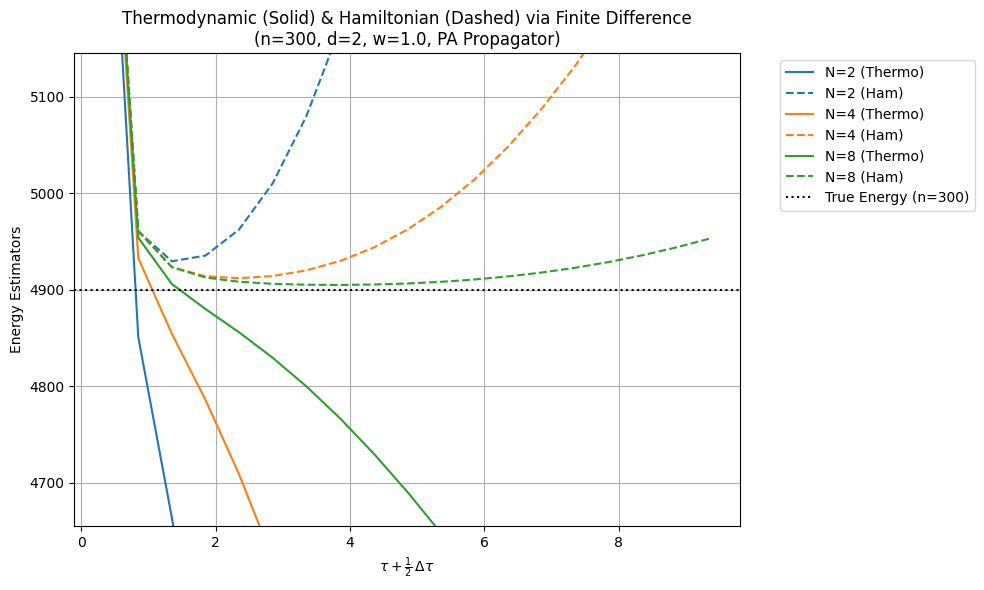

Data successfully saved to 'plot_data_n300_w1_0_T_all_n.npy' (shape (300, 3, 19)) and 'plot_data_n300_w1_0_H_all_n.npy' (shape (300, 3, 19))
Axes mapping: n (axis 0), beads (axis 1) -> 'plot_data_n300_w1_0_beads.npy', taus (axis 2) -> 'plot_data_n300_w1_0_taus.npy'


In [18]:
n_val = 300
w_val = 1.0

results = plot_polyconv_vs_tau_dual(
    n=n_val,
    d=2,
    N_list=[2, 4, 8],
    w=w_val,
    tau_start=0.1,
    tau_end=10.0,
    tau_step=0.5,
    save_filename=f"plot_data_n{n_val}_w{str(w_val).replace('.', '_')}",
    store_all_n=True
)


Loaded data successfully.
arr_T shape: (300, 3, 19) (n, beads, taus)


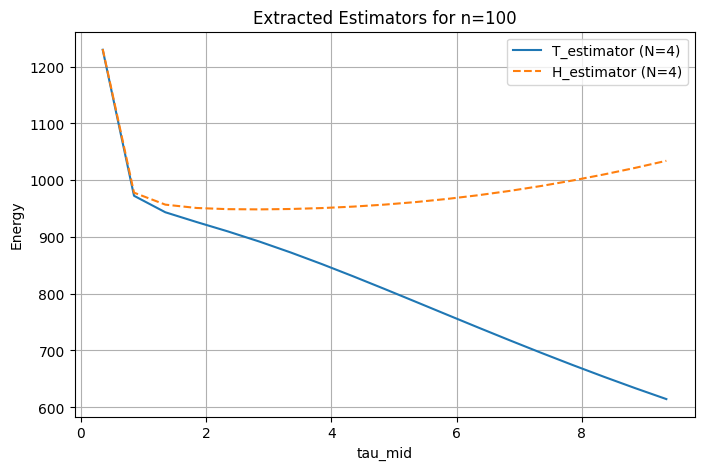

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

n_val = 300
w_val = 1.0
save_filename = f"plot_data_n{n_val}_w{str(w_val).replace('.', '_')}"

try:
    arr_T = np.load(f"{save_filename}_T_all_n.npy")
    arr_H = np.load(f"{save_filename}_H_all_n.npy")
    taus = np.load(f"{save_filename}_taus.npy")
    beads = np.load(f"{save_filename}_beads.npy")

    print("Loaded data successfully.")
    print("arr_T shape:", arr_T.shape, "(n, beads, taus)")
    
    n_plot = 99 #index, n is +1
    bead_idx = 1
    
    if n_plot < arr_T.shape[0]:
        plt.figure(figsize=(8, 5))
        plt.plot(taus, arr_T[n_plot, bead_idx, :], label=f"T_estimator (N={beads[bead_idx]})")
        plt.plot(taus, arr_H[n_plot, bead_idx, :], label=f"H_estimator (N={beads[bead_idx]})", linestyle="--")
        plt.xlabel("tau_mid")
        plt.ylabel("Energy")
        plt.title(f"Extracted Estimators for n={n_plot+1}")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print(f"Requested n_plot={n_plot} is out of bounds for saved n_max={arr_T.shape[0]-1}")
        
except FileNotFoundError:
    print("Saved files not found. Run the previous cell with store_all_n=True first.")
